# **import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import scipy

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,f1_score)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight


from xgboost import XGBClassifier

import joblib

# Read csv file

In [2]:
df = pd.read_csv("C:\\Users\\technology\\Desktop\\US_Accidents_March23.csv")

In [3]:
df

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.010,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.010,...,False,False,False,False,True,False,Day,Day,Day,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728389,A-7777757,Source1,2,2019-08-23 18:03:25,2019-08-23 18:32:01,34.002480,-117.379360,33.99888,-117.37094,0.543,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,A-7777758,Source1,2,2019-08-23 19:11:30,2019-08-23 19:38:23,32.766960,-117.148060,32.76555,-117.15363,0.338,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,A-7777759,Source1,2,2019-08-23 19:00:21,2019-08-23 19:28:49,33.775450,-117.847790,33.77740,-117.85727,0.561,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,A-7777760,Source1,2,2019-08-23 19:00:21,2019-08-23 19:29:42,33.992460,-118.403020,33.98311,-118.39565,0.772,...,False,False,False,False,False,False,Day,Day,Day,Day


# Data Understanding

In [4]:
df.shape

(7728394, 46)

In [5]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [6]:
df.tail()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7728389,A-7777757,Source1,2,2019-08-23 18:03:25,2019-08-23 18:32:01,34.00248,-117.37936,33.99888,-117.37094,0.543,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,A-7777758,Source1,2,2019-08-23 19:11:30,2019-08-23 19:38:23,32.76696,-117.14806,32.76555,-117.15363,0.338,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,A-7777759,Source1,2,2019-08-23 19:00:21,2019-08-23 19:28:49,33.77545,-117.84779,33.77740,-117.85727,0.561,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,A-7777760,Source1,2,2019-08-23 19:00:21,2019-08-23 19:29:42,33.99246,-118.40302,33.98311,-118.39565,0.772,...,False,False,False,False,False,False,Day,Day,Day,Day
7728393,A-7777761,Source1,2,2019-08-23 18:52:06,2019-08-23 19:21:31,34.13393,-117.23092,34.13736,-117.23934,0.537,...,False,False,False,False,False,False,Day,Day,Day,Day


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [8]:
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7728394.00,7728394.00,7728394.00,4325632.00,4325632.00,7728394.00,7564541.00,5729375.00,7554250.00,7587715.00,7551296.00,7157161.00,5524808.00
mean,2.21,36.20,-94.70,36.26,-95.73,0.56,61.66,58.25,64.83,29.54,9.09,7.69,0.01
std,0.49,5.08,17.39,5.27,18.11,1.78,19.01,22.39,22.82,1.01,2.69,5.42,0.11
min,1.00,24.55,-124.62,24.57,-124.55,0.00,-89.00,-89.00,1.00,0.00,0.00,0.00,0.00
25%,2.00,33.40,-117.22,33.46,-117.75,0.00,49.00,43.00,48.00,29.37,10.00,4.60,0.00
50%,2.00,35.82,-87.77,36.18,-88.03,0.03,64.00,62.00,67.00,29.86,10.00,7.00,0.00
75%,2.00,40.08,-80.35,40.18,-80.25,0.46,76.00,75.00,84.00,30.03,10.00,10.40,0.00
max,4.00,49.00,-67.11,49.08,-67.11,441.75,207.00,207.00,100.00,58.63,140.00,1087.00,36.47


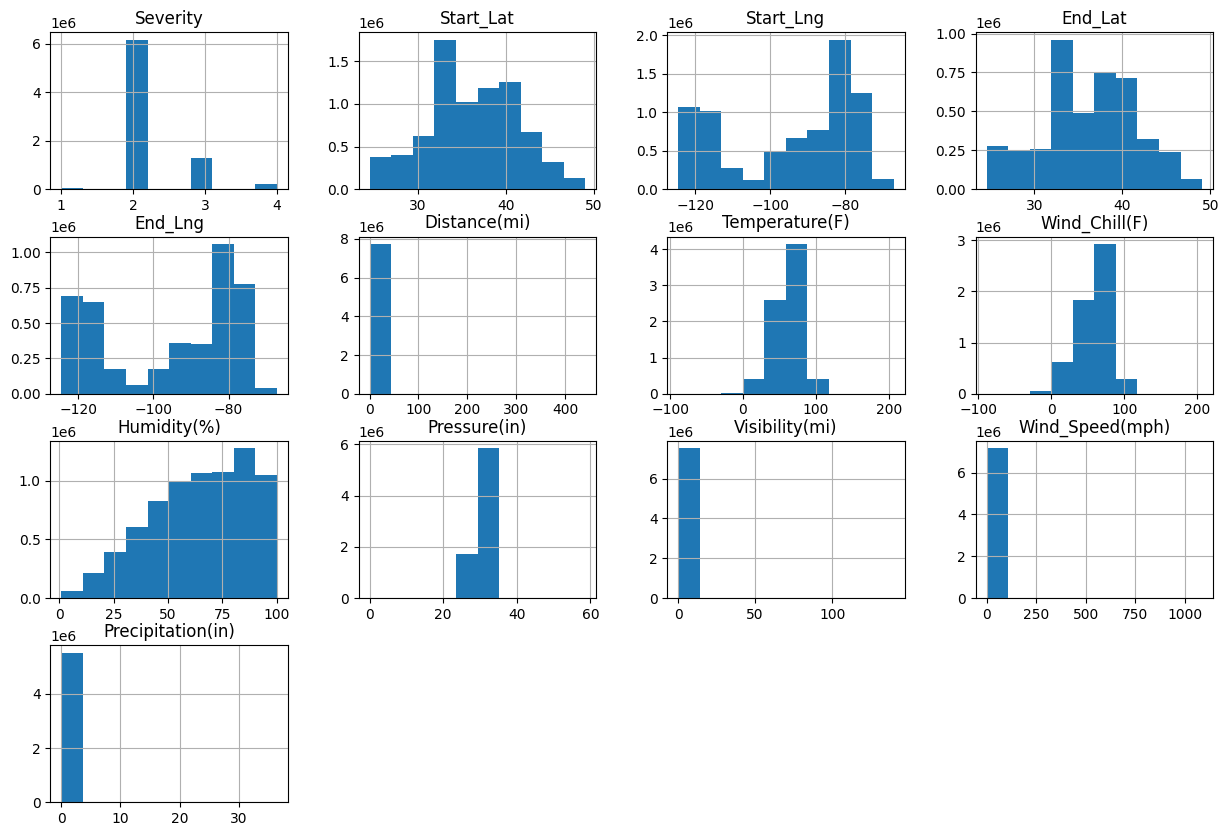

In [9]:
df.hist(figsize=(15,10))   # histogram of all  numericcolumns
plt.show()

# Check Missing Values

In [10]:
(df.isnull().sum() / len(df) * 100)   #percentage of null values in each column

ID                       0.00
Source                   0.00
Severity                 0.00
Start_Time               0.00
End_Time                 0.00
Start_Lat                0.00
Start_Lng                0.00
End_Lat                 44.03
End_Lng                 44.03
Distance(mi)             0.00
Description              0.00
Street                   0.14
City                     0.00
County                   0.00
State                    0.00
Zipcode                  0.02
Country                  0.00
Timezone                 0.10
Airport_Code             0.29
Weather_Timestamp        1.56
Temperature(F)           2.12
Wind_Chill(F)           25.87
Humidity(%)              2.25
Pressure(in)             1.82
Visibility(mi)           2.29
Wind_Direction           2.27
Wind_Speed(mph)          7.39
Precipitation(in)       28.51
Weather_Condition        2.24
Amenity                  0.00
Bump                     0.00
Crossing                 0.00
Give_Way                 0.00
Junction  

# Data Cleaning

In [11]:
# make copy of dataset
df_clean = df.copy()

In [12]:
X = df_clean.drop('Severity', axis=1)
y = df_clean['Severity']

In [13]:
# drop unuseful columns
df_clean.drop(columns=["ID","Source","End_Time","Turning_Loop","Airport_Code","Zipcode","Country","Timezone","Weather_Timestamp"],inplace = True)

In [14]:
# Drob columns with more than 40% missing values
df_clean.drop(columns=["End_Lat","End_Lng","Wind_Chill(F)"],inplace=True)

In [15]:
df_clean.columns

Index(['Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'Distance(mi)',
       'Description', 'Street', 'City', 'County', 'State', 'Temperature(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

# Numerical Columns [mean or median]
* handling Missing Values
* median : Data contianing outliers

In [16]:
num_cols = ['Temperature(F)','Visibility(mi)','Pressure(in)',    
           'Humidity(%)','Wind_Speed(mph)','Precipitation(in)','Distance(mi)']

for x in num_cols:
    df_clean[x].fillna(df_clean[x].median(), inplace=True)

# Categorical Columns [mode]
* handling Missing Values

In [17]:
cat_cols = ['Weather_Condition','City','Street','Wind_Direction','Astronomical_Twilight',
            'Nautical_Twilight','Sunrise_Sunset','Civil_Twilight']

for y in cat_cols:
    df_clean[y].fillna(df_clean[y].mode()[0], inplace=True)

In [18]:
df_clean.isnull().sum()

Severity                 0
Start_Time               0
Start_Lat                0
Start_Lng                0
Distance(mi)             0
Description              5
Street                   0
City                     0
County                   0
State                    0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Sunrise_Sunset           0
Civil_Twilight           0
Nautical_Twilight        0
Astronomical_Twilight    0
dtype: int64

In [19]:
df_clean.isnull().sum().sum()

np.int64(5)

In [20]:
print("Number of duplicate rows:", df_clean.duplicated().sum())

Number of duplicate rows: 251438


In [21]:
duplicates = df_clean[df_clean.duplicated(keep=False)]
duplicates.head(10)

,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,...,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
17909,2,2016-11-21 07:02:28,38.50,-122.43,0.01,Accident on Silverado Trl Southbound at Taplin...,Silverado Trl S,Saint Helena,Napa,CA,...,False,False,False,False,False,False,Day,Day,Day,Day
17910,2,2016-11-21 07:02:28,38.50,-122.43,0.01,Accident on Silverado Trl Southbound at Taplin...,Silverado Trl S,Saint Helena,Napa,CA,...,False,False,False,False,False,False,Day,Day,Day,Day
35166,2,2016-04-19 18:03:57,38.41,-122.79,0.01,Slow traffic due to accident on CA-12 Sebastop...,Sebastopol Rd,Santa Rosa,Sonoma,CA,...,False,False,False,False,False,False,Day,Day,Day,Day
35197,2,2016-04-19 18:03:57,38.41,-122.79,0.01,Slow traffic due to accident on CA-12 Sebastop...,Sebastopol Rd,Santa Rosa,Sonoma,CA,...,False,False,False,False,False,False,Day,Day,Day,Day
35365,3,2016-04-20 17:33:58,37.86,-121.28,0.01,Accident on I-5 Northbound at Exit 465 Roth Rd.,I-5 S,French Camp,San Joaquin,CA,...,False,False,False,False,False,False,Day,Day,Day,Day
35366,3,2016-04-20 17:33:58,37.86,-121.28,0.01,Accident on I-5 Northbound at Exit 465 Roth Rd.,I-5 S,French Camp,San Joaquin,CA,...,False,False,False,False,False,False,Day,Day,Day,Day
44811,2,2016-06-27 20:04:18,33.93,-118.09,0.00,Accident on Buell St in Whittier.,Buell St,Santa Fe Springs,Los Angeles,CA,...,False,False,False,False,False,False,Day,Day,Day,Day
44846,2,2016-06-27 20:04:18,33.93,-118.09,0.00,Accident on Buell St in Whittier.,Buell St,Santa Fe Springs,Los Angeles,CA,...,False,False,False,False,False,False,Day,Day,Day,Day
55785,2,2016-12-12 16:55:20,33.74,-116.93,0.00,Accident on Shadow Ln at Meridian St.,Shadow Ln,Hemet,Riverside,CA,...,False,False,False,False,False,False,Night,Day,Day,Day
55786,2,2016-12-12 16:55:20,33.74,-116.93,0.00,Accident on Shadow Ln at Meridian St.,Shadow Ln,Hemet,Riverside,CA,...,False,False,False,False,False,False,Night,Day,Day,Day


In [22]:
print("Total rows:", len(df_clean))
print("Exact duplicates:", df_clean.duplicated().sum())
print("Unique rows:", len(df_clean.drop_duplicates()))

Total rows: 7728394
Exact duplicates: 251438
Unique rows: 7476956


In [23]:
df_clean = df_clean.drop_duplicates()

In [24]:
print(len(df_clean))

7476956


# Feature Engineering
* # Datetime Feature Extraction

In [25]:
df_clean['Start_Time'] = pd.to_datetime(df_clean['Start_Time'],format='mixed')
df_clean['Hour'] = df_clean['Start_Time'].dt.hour
df_clean['Day'] = df_clean['Start_Time'].dt.day
df_clean['Month'] = df_clean['Start_Time'].dt.month
df_clean['Year'] = df_clean['Start_Time'].dt.year

In [26]:
df_clean.drop(columns=["Start_Time"], inplace=True)

In [27]:
df_clean.describe()

,Severity,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Hour,Day,Month,Year
count,7476956.00,7476956.00,7476956.00,7476956.00,7476956.00,7476956.00,7476956.00,7476956.00,7476956.00,7476956.00,7476956.00,7476956.00,7476956.00,7476956.00
mean,2.22,36.24,-94.78,0.56,61.70,64.93,29.55,9.11,7.63,0.01,12.31,15.74,6.68,2019.88
std,0.49,5.04,17.38,1.79,18.83,22.57,1.00,2.67,5.21,0.09,5.45,8.69,3.63,1.93
min,1.00,24.55,-124.62,0.00,-89.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,2016.00
25%,2.00,33.44,-117.23,0.00,50.00,49.00,29.38,10.00,5.00,0.00,8.00,8.00,3.00,2018.00
50%,2.00,35.84,-87.88,0.02,64.00,67.00,29.86,10.00,7.00,0.00,13.00,16.00,7.00,2020.00
75%,2.00,40.09,-80.38,0.46,75.90,84.00,30.03,10.00,10.00,0.00,17.00,23.00,10.00,2022.00
max,4.00,49.00,-67.11,441.75,207.00,100.00,58.63,140.00,1087.00,36.47,23.00,31.00,12.00,2023.00


In [28]:
print(len(df_clean["Severity"]))
print(df["Severity"].value_counts())


7476956
Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64


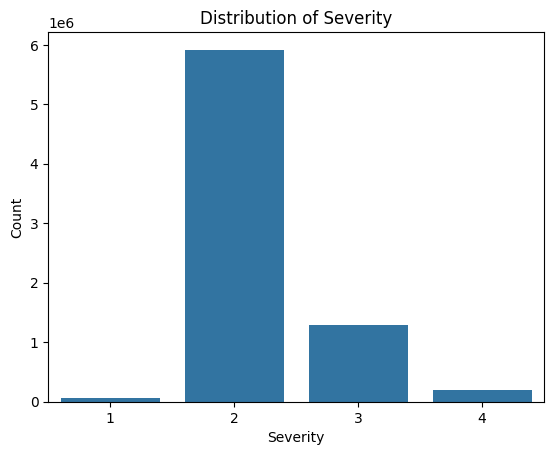

In [29]:
sns.countplot(x='Severity', data=df_clean)
plt.title('Distribution of Severity')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.show()

# Outlier Handling 

In [30]:
df_clean['Distance(mi)'] = np.log1p(df_clean['Distance(mi)'])


df_clean['Temperature(F)'] = df_clean['Temperature(F)'].clip(
    lower=8.5,
    upper=116
)


df_clean['Wind_Speed(mph)'] = df_clean['Wind_Speed(mph)'].clip(
    lower=0,
    upper=60
)


df_clean['Pressure(in)'] = df_clean['Pressure(in)'].clip(
    lower=27,
    upper=31
)

# Text Cleaning

In [31]:
from nltk.corpus import stopwords
df_clean['Description'] = df_clean['Description'].fillna('').astype(str)

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df_clean['clean_description'] = df_clean['Description'].apply(clean_text)

# Encoding
* Encode categorical columns

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# Feature Selection
* Selecting Features and Target Variable

In [33]:
# select important features
features = [

    'Start_Lat',
    'Start_Lng',

    'Distance(mi)',

    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)',

    'Hour',
    'Day',
    'Month',

    'Traffic_Signal',
    'Stop',
    'Junction',
    'Crossing',
    'Railway',
    'Roundabout',

    'Weather_Condition',
    'Wind_Direction',
    'Sunrise_Sunset'
]


In [34]:
print(df_clean.columns)

Index(['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Temperature(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Sunrise_Sunset',
       'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Hour',
       'Day', 'Month', 'Year', 'clean_description'],
      dtype='object')


In [35]:
X = df_clean[features]
X_text = df_clean['clean_description']

# Fix Impalance

In [36]:
y = df_clean['Severity']-1

# Data Segmentation

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, X_text_train, X_text_test, y_train, y_test = train_test_split(X, X_text, y, test_size = 0.2,random_state = 42,stratify=y)

# Scaling

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# TFIDF

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=3
)

X_text_train_vec = vectorizer.fit_transform(X_text_train)
X_text_test_vec = vectorizer.transform(X_text_test)

# Merge Features

In [40]:
print(X_train.dtypes)

Start_Lat            float64
Start_Lng            float64
Distance(mi)         float64
Temperature(F)       float64
Humidity(%)          float64
Pressure(in)         float64
Visibility(mi)       float64
Wind_Speed(mph)      float64
Precipitation(in)    float64
Hour                   int32
Day                    int32
Month                  int32
Traffic_Signal          bool
Stop                    bool
Junction                bool
Crossing                bool
Railway                 bool
Roundabout              bool
Weather_Condition      int64
Wind_Direction         int64
Sunrise_Sunset         int64
dtype: object


In [41]:
from scipy.sparse import hstack, csr_matrix

X_train_final = hstack([
    csr_matrix(X_train_scaled),
    X_text_train_vec
])

X_test_final = hstack([
    csr_matrix(X_test_scaled),
    X_text_test_vec
])

X_train_final = X_train_final.astype(np.float32)
X_test_final = X_test_final.astype(np.float32)

# Class Weights

In [42]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
class_weights[0] = 15 # Adjust weight for class 0

for cls, weight in class_weights.items():
    print(f"Class {cls}: {weight}")

sample_weights = pd.Series(y_train).map(class_weights).values

print(sample_weights)

Class 0: 15
Class 1: 0.3158808500570866
Class 2: 1.4447929075835175
Class 3: 9.30119919887544
[0.31588085 0.31588085 0.31588085 ... 0.31588085 0.31588085 0.31588085]


# Modeling

In [43]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

In [44]:
model.fit(
    X_train_final,
    y_train,
    sample_weight=sample_weights
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [45]:
y_proba = model.predict_proba(X_test_final)

In [46]:
thresholds = np.arange(0.3, 0.8, 0.05)

best_threshold = None
best_score = 0

for t in thresholds:
    y_pred = []

    for proba in y_proba:
        max_prob = np.max(proba)
        pred_class = np.argmax(proba)

        if max_prob < t:
           
            y_pred.append(1)
        else:
            y_pred.append(pred_class)

    score = f1_score(y_test, y_pred, average='macro')

    print(f"Threshold {t:.2f} -> Macro F1: {score:.4f}")

    if score > best_score:
        best_score = score
        best_threshold = t

print("\nBest threshold:", best_threshold)
print("Best Macro F1:", best_score)

Threshold 0.30 -> Macro F1: 0.6876
Threshold 0.35 -> Macro F1: 0.6884
Threshold 0.40 -> Macro F1: 0.6909
Threshold 0.45 -> Macro F1: 0.6963
Threshold 0.50 -> Macro F1: 0.7103
Threshold 0.55 -> Macro F1: 0.7287
Threshold 0.60 -> Macro F1: 0.7436
Threshold 0.65 -> Macro F1: 0.7568
Threshold 0.70 -> Macro F1: 0.7682
Threshold 0.75 -> Macro F1: 0.7772

Best threshold: 0.7499999999999999
Best Macro F1: 0.7771584048885181


In [47]:
y_pred_final = []

for proba in y_proba:
    max_prob = np.max(proba)
    pred_class = np.argmax(proba)

    if max_prob < best_threshold:
        y_pred_final.append(1)
    else:
        y_pred_final.append(pred_class)

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
print(cm)

              precision    recall  f1-score   support

           0       0.59      0.83      0.69     12933
           1       0.94      0.93      0.94   1183510
           2       0.81      0.76      0.79    258755
           3       0.57      0.89      0.70     40194

    accuracy                           0.90   1495392
   macro avg       0.73      0.85      0.78   1495392
weighted avg       0.91      0.90      0.90   1495392

[[  10706    2193      33       1]
 [   6840 1106023   44449   26198]
 [    620   61270  196127     738]
 [     45    3876     319   35954]]


In [49]:
param_dist = {
    'n_estimators': [150, 200, 300],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}


In [50]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

In [51]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=3,
    scoring='f1_weighted',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [52]:
sample_size = 200000

sample_idx = np.random.choice(
    X_train_final.shape[0],
    sample_size,
    replace=False
)

X_sample = X_train_final[sample_idx]
y_sample = y_train.iloc[sample_idx]

In [53]:
random_search.fit(
    X_sample,
    y_sample
)

Fitting 2 folds for each of 3 candidates, totalling 6 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=4, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [6, 8, ...], 'n_estimators': [150, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [54]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
0.9236490703468252


In [55]:
best_model = random_search.best_estimator_

In [56]:
y_pred = best_model.predict(X_test_final)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.61      0.70     12933
           1       0.94      0.97      0.96   1183510
           2       0.85      0.81      0.83    258755
           3       0.90      0.59      0.71     40194

    accuracy                           0.93   1495392
   macro avg       0.88      0.74      0.80   1495392
weighted avg       0.93      0.93      0.93   1495392



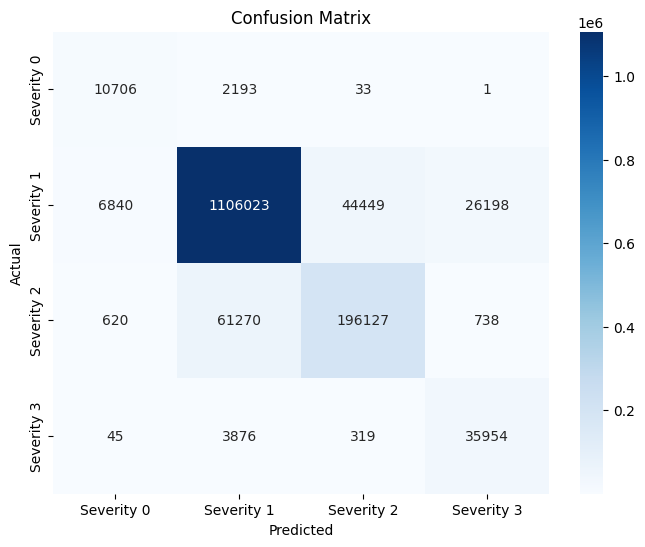

In [58]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3'],
    yticklabels=['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [61]:
# Save model
joblib.dump(model, "xgb_accident_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

# Save features
joblib.dump(features, "features.pkl")

# Save threshold
joblib.dump(best_threshold, "best_threshold.pkl")


print("All files saved successfully")

All files saved successfully
